# Cross-Dataset Generalization: LoRA-SAM Polyp Segmentation

**Model:** LoRA-adapted MobileSAM trained on **Kvasir-SEG** (rank=4, ~0.4M LoRA params)

**Evaluation datasets (all unseen during training):**
| Dataset | Images | Source |
|---------|--------|--------|
| CVC-ClinicDB | 612 | Colonoscopy sequences |
| CVC-ColonDB | ~380 | Colon polyp frames |
| ETIS-LaribPolypDB | 196 | Early-stage polyps (hardest benchmark) |

**Protocol:** 2 FG + 1 BG simulated point clicks, 4-fold flip TTA, Morphological post-processing

**Metrics:** Dice, mIoU, Precision, Recall, Specificity, F2, HD95

In [1]:
# ============================================================
# Cell 1 — Install + imports + GPU
# ============================================================
!pip -q install git+https://github.com/ChaoningZhang/MobileSAM.git
!pip -q install scipy

import os, sys, random, gc, math, time, warnings, glob
from collections import OrderedDict
from pathlib import Path

import numpy as np
import cv2
import pandas as pd
from tqdm import tqdm
from scipy.ndimage import distance_transform_edt
from scipy import stats

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm

warnings.filterwarnings("ignore")
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

from mobile_sam import sam_model_registry
from mobile_sam.utils.transforms import ResizeLongestSide

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"DEVICE: {DEVICE}")
if DEVICE == "cuda":
    gpu = torch.cuda.get_device_properties(0)
    print(f"GPU: {torch.cuda.get_device_name(0)} | "
          f"VRAM: {gpu.total_memory / 1e9:.2f} GB")

  Preparing metadata (setup.py) ... done
DEVICE: cuda
GPU: Tesla T4 | VRAM: 15.64 GB


In [2]:
# ============================================================
# Cell 2 — Configuration + dataset / model paths
# ============================================================
SEED          = 42
SAM_IMG_SIZE  = 1024
N_FG_POINTS   = 2
N_BG_POINTS   = 1
LORA_RANK     = 4
LORA_ALPHA    = 1.0
LORA_DROPOUT  = 0.05
USE_TTA       = True   # Set False for faster eval (slightly lower scores)

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if DEVICE == "cuda":
    torch.cuda.manual_seed_all(SEED)

IMG_EXT = {'.png'}

# -------------------- Model checkpoint --------------------
pth_files = sorted(glob.glob('/kaggle/input/**/*.pth', recursive=True))
MODEL_PATH = None
for f in pth_files:
    if 'lorasam' in f.lower() or 'best' in f.lower():
        MODEL_PATH = f
        break
if MODEL_PATH is None and pth_files:
    MODEL_PATH = pth_files[0]
assert MODEL_PATH, "No .pth file found! Add your trained model."
print(f"MODEL: {MODEL_PATH}  ({os.path.getsize(MODEL_PATH)/1e6:.1f} MB)")

# -------------------- Dataset paths (hardcoded for Kaggle) --------------------
DATASETS = OrderedDict({
    'CVC-ClinicDB': {
        'img_dir':  '/kaggle/input/datasets/balraj98/cvcclinicdb/PNG/Original',
        'mask_dir': '/kaggle/input/datasets/balraj98/cvcclinicdb/PNG/Ground Truth',
    },
    'CVC-ColonDB': {
        'img_dir':  '/kaggle/input/datasets/longvil/cvc-colondb/CVC-ColonDB/images',
        'mask_dir': '/kaggle/input/datasets/longvil/cvc-colondb/CVC-ColonDB/masks',
    },
    'ETIS-LaribPolypDB': {
        'img_dir':  '/kaggle/input/datasets/nguyenvoquocduong/etis-laribpolypdb/images',
        'mask_dir': '/kaggle/input/datasets/nguyenvoquocduong/etis-laribpolypdb/masks',
    },
})

# -------------------- Verify all paths exist --------------------
print(f"\n{'='*70}")
print(f"  DATASETS")
print(f"{'='*70}")
for name, p in DATASETS.items():
    assert os.path.isdir(p['img_dir']),  f"NOT FOUND: {p['img_dir']}"
    assert os.path.isdir(p['mask_dir']), f"NOT FOUND: {p['mask_dir']}"
    ni = len([f for f in os.listdir(p['img_dir'])  if f.lower().endswith('.png')])
    nm = len([f for f in os.listdir(p['mask_dir']) if f.lower().endswith('.png')])
    print(f"\n  {name}: {ni} images, {nm} masks")
    print(f"    img:  {p['img_dir']}")
    print(f"    mask: {p['mask_dir']}")
print(f"{'='*70}")
print(f"\n  All 3 datasets verified. Ready to evaluate.")

MODEL: /kaggle/input/models/haryshwa/lorasam/pytorch/default/1/lorasam_kvasir_best.pth  (41.3 MB)

  DATASETS

  CVC-ClinicDB: 612 images, 612 masks
    img:  /kaggle/input/datasets/balraj98/cvcclinicdb/PNG/Original
    mask: /kaggle/input/datasets/balraj98/cvcclinicdb/PNG/Ground Truth

  CVC-ColonDB: 380 images, 380 masks
    img:  /kaggle/input/datasets/longvil/cvc-colondb/CVC-ColonDB/images
    mask: /kaggle/input/datasets/longvil/cvc-colondb/CVC-ColonDB/masks

  ETIS-LaribPolypDB: 196 images, 196 masks
    img:  /kaggle/input/datasets/nguyenvoquocduong/etis-laribpolypdb/images
    mask: /kaggle/input/datasets/nguyenvoquocduong/etis-laribpolypdb/masks

  All 3 datasets verified. Ready to evaluate.


In [3]:
# ============================================================
# Cell 3 — LoRA implementation + build & load model
# ============================================================
class LoRALinear(nn.Module):
    def __init__(self, original_linear: nn.Linear, rank=4, alpha=1.0, dropout=0.0):
        super().__init__()
        self.in_features  = original_linear.in_features
        self.out_features = original_linear.out_features
        self.rank    = rank
        self.scaling = alpha / rank
        self.linear  = original_linear
        self.linear.weight.requires_grad = False
        if self.linear.bias is not None:
            self.linear.bias.requires_grad = False
        self.lora_A = nn.Linear(self.in_features, rank, bias=False)
        self.lora_B = nn.Linear(rank, self.out_features, bias=False)
        self.lora_dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()
        nn.init.kaiming_uniform_(self.lora_A.weight, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B.weight)

    def forward(self, x):
        return self.linear(x) + self.lora_B(self.lora_A(self.lora_dropout(x))) * self.scaling


def inject_lora(model, rank=4, alpha=1.0, dropout=0.0, target_modules=None):
    targets = []
    for name, module in model.named_modules():
        for child_name, child in module.named_children():
            if not isinstance(child, nn.Linear):
                continue
            full_name = f"{name}.{child_name}" if name else child_name
            if target_modules and not any(t in full_name for t in target_modules):
                continue
            targets.append((module, child_name, child, full_name))
    injected = []
    for parent, child_name, child, full_name in targets:
        lora_layer = LoRALinear(child, rank=rank, alpha=alpha, dropout=dropout)
        setattr(parent, child_name, lora_layer)
        injected.append((full_name, lora_layer))
    return injected

# ---------- Build architecture (no pretrained needed — we load full state_dict) ----------
sam = sam_model_registry["vit_t"](checkpoint=None)

for p in sam.parameters():
    p.requires_grad = False

lora_layers = inject_lora(
    sam.image_encoder, rank=LORA_RANK, alpha=LORA_ALPHA, dropout=LORA_DROPOUT
)

# ---------- Load fine-tuned checkpoint (contains ALL weights) ----------
state_dict = torch.load(MODEL_PATH, map_location="cpu", weights_only=True)
sam.load_state_dict(state_dict, strict=True)
sam = sam.to(DEVICE)
sam.eval()

lora_params = sum(
    sum(p.numel() for p in layer.lora_A.parameters()) +
    sum(p.numel() for p in layer.lora_B.parameters())
    for _, layer in lora_layers
)
total_params = sum(p.numel() for p in sam.parameters())
print(f"Model loaded successfully!")
print(f"  LoRA layers: {len(lora_layers)}  |  LoRA params: {lora_params/1e3:.1f}K")
print(f"  Total params: {total_params/1e6:.2f}M")
print(f"  Checkpoint: {MODEL_PATH}")

Model loaded successfully!
  LoRA layers: 41  |  LoRA params: 124.1K
  Total params: 10.25M
  Checkpoint: /kaggle/input/models/haryshwa/lorasam/pytorch/default/1/lorasam_kvasir_best.pth


In [4]:
# ============================================================
# Cell 4 — Point sampling + evaluation dataset + data loaders
# ============================================================
sam_transform = ResizeLongestSide(SAM_IMG_SIZE)

def sample_points(mask01, n_fg=2, n_bg=1):
    H, W = mask01.shape
    ys_fg, xs_fg = np.where(mask01 > 0.5)
    ys_bg, xs_bg = np.where(mask01 <= 0.5)

    if len(xs_fg) == 0:
        idx = np.random.choice(len(xs_bg), size=n_fg + n_bg, replace=True)
        pts = np.stack([xs_bg[idx], ys_bg[idx]], axis=1).astype(np.float32)
        labels = np.array([1]*n_fg + [0]*n_bg, dtype=np.int64)
        return pts, labels

    fg_pts = [[float(xs_fg.mean()), float(ys_fg.mean())]]
    if n_fg > 1:
        idx = np.random.choice(len(xs_fg), size=n_fg - 1, replace=True)
        for j in idx:
            fg_pts.append([float(xs_fg[j]), float(ys_fg[j])])

    bg_pts = []
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    dilated = cv2.dilate(mask01.astype(np.uint8), kernel, iterations=3)
    near_bg = (dilated > 0) & (mask01 <= 0.5)
    nby, nbx = np.where(near_bg)
    if len(nbx) >= n_bg:
        nidx = np.random.choice(len(nbx), size=n_bg, replace=False)
        for j in nidx:
            bg_pts.append([float(nbx[j]), float(nby[j])])
    else:
        idx = np.random.choice(len(xs_bg), size=n_bg, replace=True)
        for j in idx:
            bg_pts.append([float(xs_bg[j]), float(ys_bg[j])])

    all_pts = np.array(fg_pts + bg_pts, dtype=np.float32)
    labels  = np.array([1]*len(fg_pts) + [0]*len(bg_pts), dtype=np.int64)
    all_pts[:, 0] = np.clip(all_pts[:, 0], 0, W - 1)
    all_pts[:, 1] = np.clip(all_pts[:, 1], 0, H - 1)
    return all_pts, labels


class PolypEvalDataset(Dataset):
    def __init__(self, img_dir, mask_dir):
        self.img_dir  = img_dir
        self.mask_dir = mask_dir
        img_files = sorted(f for f in os.listdir(img_dir)
                           if Path(f).suffix.lower() in IMG_EXT)
        msk_files = sorted(f for f in os.listdir(mask_dir)
                           if Path(f).suffix.lower() in IMG_EXT)

        img_stems = {Path(f).stem: f for f in img_files}
        msk_stems = {Path(f).stem: f for f in msk_files}
        common = sorted(set(img_stems) & set(msk_stems))

        if common:
            self.pairs = [(img_stems[s], msk_stems[s]) for s in common]
        else:
            n = min(len(img_files), len(msk_files))
            self.pairs = list(zip(img_files[:n], msk_files[:n]))
        assert len(self.pairs) > 0, f"No pairs in {img_dir} / {mask_dir}"

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_name, msk_name = self.pairs[idx]
        image = cv2.cvtColor(
            cv2.imread(os.path.join(self.img_dir, img_name)), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(os.path.join(self.mask_dir, msk_name), cv2.IMREAD_GRAYSCALE)
        if mask is None:
            mask = cv2.cvtColor(
                cv2.imread(os.path.join(self.mask_dir, msk_name)), cv2.COLOR_BGR2GRAY)
        mask01 = (mask > 127).astype(np.float32)
        H, W = mask01.shape

        pts_xy, pt_labels = sample_points(mask01, n_fg=N_FG_POINTS, n_bg=N_BG_POINTS)
        image_resized  = sam_transform.apply_image(image)
        pts_xy_resized = sam_transform.apply_coords(pts_xy, (H, W))

        image_t  = torch.as_tensor(image_resized, dtype=torch.float32).permute(2, 0, 1)
        points_t = torch.as_tensor(pts_xy_resized, dtype=torch.float32)
        labels_t = torch.as_tensor(pt_labels, dtype=torch.int64)
        mask_t   = torch.as_tensor(mask01, dtype=torch.float32)
        return image_t, points_t, labels_t, mask_t, (H, W), img_name


# Build data loaders for every discovered dataset
data_loaders = OrderedDict()
for ds_name, paths in DATASETS.items():
    ds = PolypEvalDataset(paths['img_dir'], paths['mask_dir'])
    loader = DataLoader(ds, batch_size=1, shuffle=False,
                        num_workers=2, pin_memory=True)
    data_loaders[ds_name] = loader
    print(f"  {ds_name}: {len(ds)} image-mask pairs")

total_imgs = sum(len(ld.dataset) for ld in data_loaders.values())
print(f"\nTotal images to evaluate: {total_imgs}")

  CVC-ClinicDB: 612 image-mask pairs
  CVC-ColonDB: 380 image-mask pairs
  ETIS-LaribPolypDB: 196 image-mask pairs

Total images to evaluate: 1188


In [5]:
# ============================================================
# Cell 5 — Inference pipeline (forward + TTA + post-processing)
# ============================================================
@torch.no_grad()
def forward_sam_points(image_t, points_t, labels_t):
    img = sam.preprocess(image_t.unsqueeze(0).to(DEVICE))
    emb = sam.image_encoder(img)
    pts = (points_t.unsqueeze(0).to(DEVICE), labels_t.unsqueeze(0).to(DEVICE))
    sparse, dense = sam.prompt_encoder(points=pts, boxes=None, masks=None)
    low_res, _ = sam.mask_decoder(
        image_embeddings=emb,
        image_pe=sam.prompt_encoder.get_dense_pe(),
        sparse_prompt_embeddings=sparse,
        dense_prompt_embeddings=dense,
        multimask_output=False,
    )
    return low_res

@torch.no_grad()
def predict_tta(image_t, points_t, labels_t, orig_hw):
    H, W = orig_hw
    if not USE_TTA:
        with autocast(device_type="cuda"):
            lr = forward_sam_points(image_t, points_t, labels_t)
        return F.interpolate(lr, size=(H, W), mode="bilinear", align_corners=False)

    img_np    = image_t.permute(1, 2, 0).numpy()
    pts_np    = points_t.numpy()
    labels_np = labels_t.numpy()
    _, h_r, w_r = image_t.shape
    accum = None

    for hflip, vflip in [(False, False), (True, False), (False, True), (True, True)]:
        ia, pa = img_np.copy(), pts_np.copy()
        if hflip:
            ia = np.flip(ia, axis=1).copy()
            pa[:, 0] = w_r - 1 - pa[:, 0]
        if vflip:
            ia = np.flip(ia, axis=0).copy()
            pa[:, 1] = h_r - 1 - pa[:, 1]

        it = torch.as_tensor(ia, dtype=torch.float32).permute(2, 0, 1)
        pt = torch.as_tensor(pa, dtype=torch.float32)
        lt = torch.as_tensor(labels_np, dtype=torch.int64)

        with autocast(device_type="cuda"):
            lr = forward_sam_points(it, pt, lt).float().cpu().numpy()[0, 0]

        if vflip: lr = np.flip(lr, axis=0).copy()
        if hflip: lr = np.flip(lr, axis=1).copy()
        accum = lr.astype(np.float64) if accum is None else accum + lr

    avg = torch.as_tensor((accum / 4).astype(np.float32)).unsqueeze(0).unsqueeze(0)
    return F.interpolate(avg, size=(H, W), mode="bilinear", align_corners=False)


def postprocess(pred):
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    out = cv2.morphologyEx(pred, cv2.MORPH_OPEN,  k, iterations=1)
    out = cv2.morphologyEx(out,  cv2.MORPH_CLOSE, k, iterations=2)
    return out

tta_label = "4-fold flip" if USE_TTA else "disabled"
print(f"Inference pipeline ready.  TTA: {tta_label}  |  Post-proc: morph open+close")

Inference pipeline ready.  TTA: 4-fold flip  |  Post-proc: morph open+close


In [6]:
# ============================================================
# Cell 6 — Research-grade metrics
# ============================================================
def _border(m, w=1):
    k = cv2.getStructuringElement(cv2.MORPH_CROSS, (3, 3))
    return m.astype(np.uint8) - cv2.erode(m.astype(np.uint8), k, iterations=w)

def hausdorff95(pred01, gt01):
    pb, gb = _border(pred01), _border(gt01)
    if pb.sum() == 0 or gb.sum() == 0:
        return float("nan")
    dt_gt   = distance_transform_edt(1 - gb)
    dt_pred = distance_transform_edt(1 - pb)
    dists = np.concatenate([dt_gt[pb > 0], dt_pred[gb > 0]])
    return float(np.percentile(dists, 95))

def compute_metrics(pred01, gt01, eps=1e-6):
    p, g = pred01.astype(bool), gt01.astype(bool)
    tp = (p & g).sum();  fp = (p & ~g).sum()
    fn = (~p & g).sum(); tn = (~p & ~g).sum()
    return {
        "Dice":        (2*tp+eps) / (2*tp+fp+fn+eps),
        "IoU":         (tp+eps) / (tp+fp+fn+eps),
        "Precision":   (tp+eps) / (tp+fp+eps),
        "Recall":      (tp+eps) / (tp+fn+eps),
        "Specificity": (tn+eps) / (tn+fp+eps),
        "F2":          (5*tp+eps) / (5*tp+4*fn+fp+eps),
        "HD95":        hausdorff95(pred01, gt01),
    }

METRIC_COLS = ["Dice", "IoU", "Precision", "Recall", "Specificity", "F2", "HD95"]
print("Metrics defined: " + ", ".join(METRIC_COLS))

Metrics defined: Dice, IoU, Precision, Recall, Specificity, F2, HD95


In [7]:
# ============================================================
# Cell 7 — Core evaluation function (reusable per dataset)
# ============================================================
@torch.no_grad()
def evaluate_dataset(loader, dataset_name):
    sam.eval()
    results = []
    for (image_t, points_t, labels_t, mask_t, (H, W), name) in tqdm(
        loader, desc=dataset_name
    ):
        gt01 = (mask_t[0].numpy() > 0.5).astype(np.uint8)
        logits = predict_tta(image_t[0], points_t[0], labels_t[0], (H, W))
        probs = torch.sigmoid(logits)[0, 0].cpu().numpy()
        pred = postprocess((probs > 0.5).astype(np.uint8))

        m = compute_metrics(pred, gt01)
        m["name"]    = name[0]
        m["dataset"] = dataset_name
        results.append(m)

    return pd.DataFrame(results)

print("Evaluation function defined.")

Evaluation function defined.


In [8]:
# ============================================================
# Cell 8 — Run cross-dataset evaluation (each dataset separately)
# ============================================================
print("=" * 70)
print("  CROSS-DATASET EVALUATION  —  LoRA-SAM (trained on Kvasir-SEG)")
print("=" * 70)

all_results = OrderedDict()
t0 = time.time()

for ds_name, loader in data_loaders.items():
    n = len(loader.dataset)
    print(f"\n{'─'*60}")
    print(f"  >>> {ds_name}  ({n} images)")
    print(f"{'─'*60}")

    df = evaluate_dataset(loader, ds_name)
    all_results[ds_name] = df

    print(f"\n  {ds_name} results (mean +/- std):")
    for m in METRIC_COLS:
        v = df[m].dropna()
        print(f"    {m:14s}: {v.mean():.4f} +/- {v.std():.4f}")

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

elapsed = (time.time() - t0) / 60
print(f"\n{'='*70}")
print(f"  All evaluations complete!  Total time: {elapsed:.1f} min")
print(f"{'='*70}")

df_all = pd.concat(list(all_results.values()), ignore_index=True)
ds_names = list(all_results.keys())
n_ds = len(ds_names)

  CROSS-DATASET EVALUATION  —  LoRA-SAM (trained on Kvasir-SEG)

────────────────────────────────────────────────────────────
  >>> CVC-ClinicDB  (612 images)
────────────────────────────────────────────────────────────


CVC-ClinicDB: 100%|██████████| 612/612 [02:38<00:00,  3.86it/s]



  CVC-ClinicDB results (mean +/- std):
    Dice          : 0.8554 +/- 0.1236
    IoU           : 0.7635 +/- 0.1523
    Precision     : 0.8682 +/- 0.1473
    Recall        : 0.8633 +/- 0.1185
    Specificity   : 0.9881 +/- 0.0179
    F2            : 0.8566 +/- 0.1179
    HD95          : 18.5570 +/- 19.8157

────────────────────────────────────────────────────────────
  >>> CVC-ColonDB  (380 images)
────────────────────────────────────────────────────────────


CVC-ColonDB: 100%|██████████| 380/380 [01:44<00:00,  3.63it/s]



  CVC-ColonDB results (mean +/- std):
    Dice          : 0.8574 +/- 0.1312
    IoU           : 0.7694 +/- 0.1676
    Precision     : 0.8467 +/- 0.1556
    Recall        : 0.8985 +/- 0.1223
    Specificity   : 0.9922 +/- 0.0121
    F2            : 0.8759 +/- 0.1224
    HD95          : 22.1937 +/- 26.5293

────────────────────────────────────────────────────────────
  >>> ETIS-LaribPolypDB  (196 images)
────────────────────────────────────────────────────────────


ETIS-LaribPolypDB: 100%|██████████| 196/196 [01:13<00:00,  2.67it/s]



  ETIS-LaribPolypDB results (mean +/- std):
    Dice          : 0.7905 +/- 0.1856
    IoU           : 0.6850 +/- 0.2096
    Precision     : 0.7558 +/- 0.2214
    Recall        : 0.8907 +/- 0.1062
    Specificity   : 0.9921 +/- 0.0081
    F2            : 0.8292 +/- 0.1545
    HD95          : 59.8081 +/- 109.3456

  All evaluations complete!  Total time: 5.6 min


In [9]:
# ============================================================
# Cell 9 — Cross-dataset comparison table + LaTeX
# ============================================================
print("\n" + "=" * 105)
print("  CROSS-DATASET RESULTS: LoRA-SAM  (Kvasir-SEG  -->  unseen datasets)")
print("=" * 105)

header = f"{'Dataset':<22}"
for m in METRIC_COLS:
    header += f" {m:>12}"
print(header)
print("-" * 105)

summary_rows = []
for ds_name, df in all_results.items():
    row = {"Dataset": ds_name, "N": len(df)}
    line = f"{ds_name:<22}"
    for m in METRIC_COLS:
        v = df[m].dropna()
        line += f" {v.mean():>12.4f}"
        row[f"{m}_mean"] = round(v.mean(), 4)
        row[f"{m}_std"]  = round(v.std(), 4)
    print(line)
    summary_rows.append(row)

print("-" * 105)
line_avg = f"{'OVERALL AVERAGE':<22}"
for m in METRIC_COLS:
    v = df_all[m].dropna()
    line_avg += f" {v.mean():>12.4f}"
print(line_avg)
print("=" * 105)

df_summary = pd.DataFrame(summary_rows)

# ---- LaTeX table ----
print("\n--- LaTeX Table ---")
hdr = "Dataset & N & " + " & ".join(METRIC_COLS)
print("\\begin{table}[h]")
print("\\centering")
print("\\caption{Cross-dataset generalization of LoRA-SAM (trained on Kvasir-SEG)}")
print("\\begin{tabular}{lc" + "c" * len(METRIC_COLS) + "}")
print("\\toprule")
print(hdr + " \\\\")
print("\\midrule")
for ds_name, df in all_results.items():
    vals = " & ".join(f"{df[m].dropna().mean():.4f}" for m in METRIC_COLS)
    print(f"{ds_name} & {len(df)} & {vals} \\\\")
print("\\bottomrule")
print("\\end{tabular}")
print("\\end{table}")


  CROSS-DATASET RESULTS: LoRA-SAM  (Kvasir-SEG  -->  unseen datasets)
Dataset                        Dice          IoU    Precision       Recall  Specificity           F2         HD95
---------------------------------------------------------------------------------------------------------
CVC-ClinicDB                 0.8554       0.7635       0.8682       0.8633       0.9881       0.8566      18.5570
CVC-ColonDB                  0.8574       0.7694       0.8467       0.8985       0.9922       0.8759      22.1937
ETIS-LaribPolypDB            0.7905       0.6850       0.7558       0.8907       0.9921       0.8292      59.8081
---------------------------------------------------------------------------------------------------------
OVERALL AVERAGE              0.8454       0.7525       0.8427       0.8791       0.9900       0.8582      26.5260

--- LaTeX Table ---
\begin{table}[h]
\centering
\caption{Cross-dataset generalization of LoRA-SAM (trained on Kvasir-SEG)}
\begin{tabular}{lcccccc

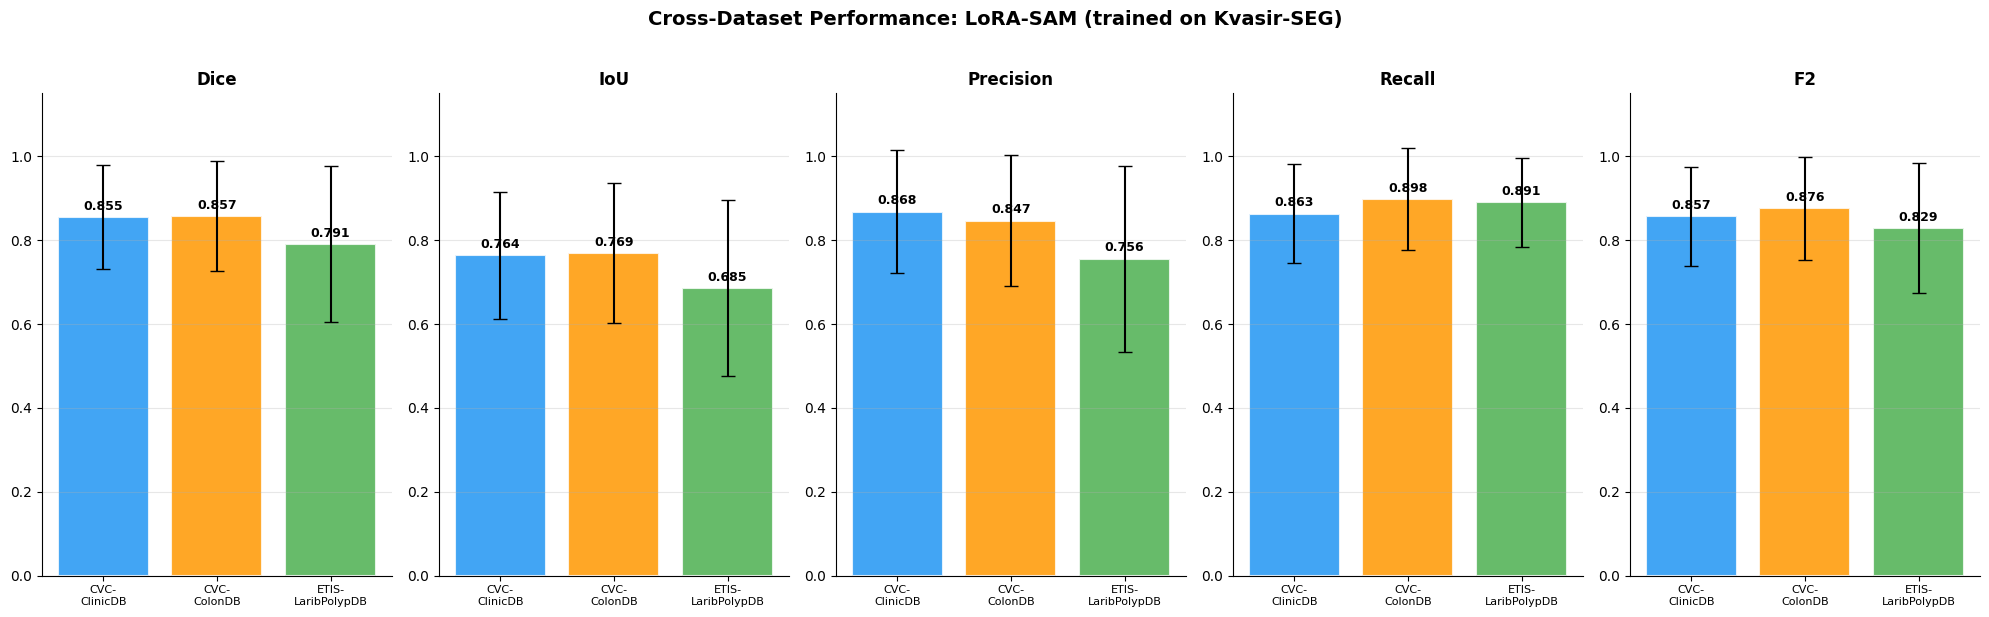

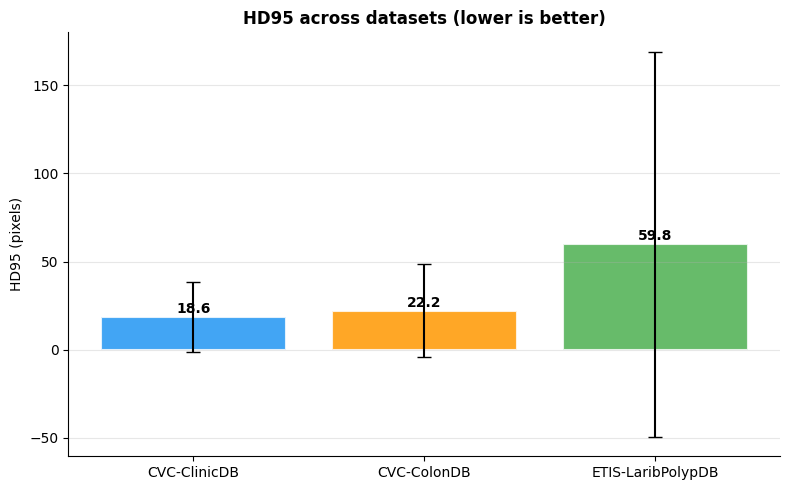

In [10]:
# ============================================================
# Cell 10 — Metric comparison bar charts
# ============================================================
colors = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63', '#9C27B0'][:n_ds]

plot_metrics = ["Dice", "IoU", "Precision", "Recall", "F2"]
fig, axes = plt.subplots(1, len(plot_metrics), figsize=(4 * len(plot_metrics), 6))
if len(plot_metrics) == 1:
    axes = [axes]

for ax, metric in zip(axes, plot_metrics):
    means = [all_results[ds][metric].dropna().mean() for ds in ds_names]
    stds  = [all_results[ds][metric].dropna().std()  for ds in ds_names]
    bars = ax.bar(range(n_ds), means, yerr=stds, color=colors,
                  capsize=5, edgecolor='white', linewidth=1.5, alpha=0.85)
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_xticks(range(n_ds))
    xlabels = [n.replace('CVC-', 'CVC-\n').replace('ETIS-', 'ETIS-\n') for n in ds_names]
    ax.set_xticklabels(xlabels, fontsize=8)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.15)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Cross-Dataset Performance: LoRA-SAM (trained on Kvasir-SEG)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("cross_dataset_bars.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- HD95 bar chart (lower is better) ----
fig, ax = plt.subplots(figsize=(8, 5))
means = [all_results[ds]["HD95"].dropna().mean() for ds in ds_names]
stds  = [all_results[ds]["HD95"].dropna().std()  for ds in ds_names]
bars = ax.bar(range(n_ds), means, yerr=stds, color=colors,
              capsize=5, edgecolor='white', linewidth=1.5, alpha=0.85)
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_xticks(range(n_ds))
ax.set_xticklabels(ds_names, fontsize=10)
ax.set_title('HD95 across datasets (lower is better)', fontsize=12, fontweight='bold')
ax.set_ylabel('HD95 (pixels)')
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("cross_dataset_hd95.png", dpi=150, bbox_inches="tight")
plt.show()

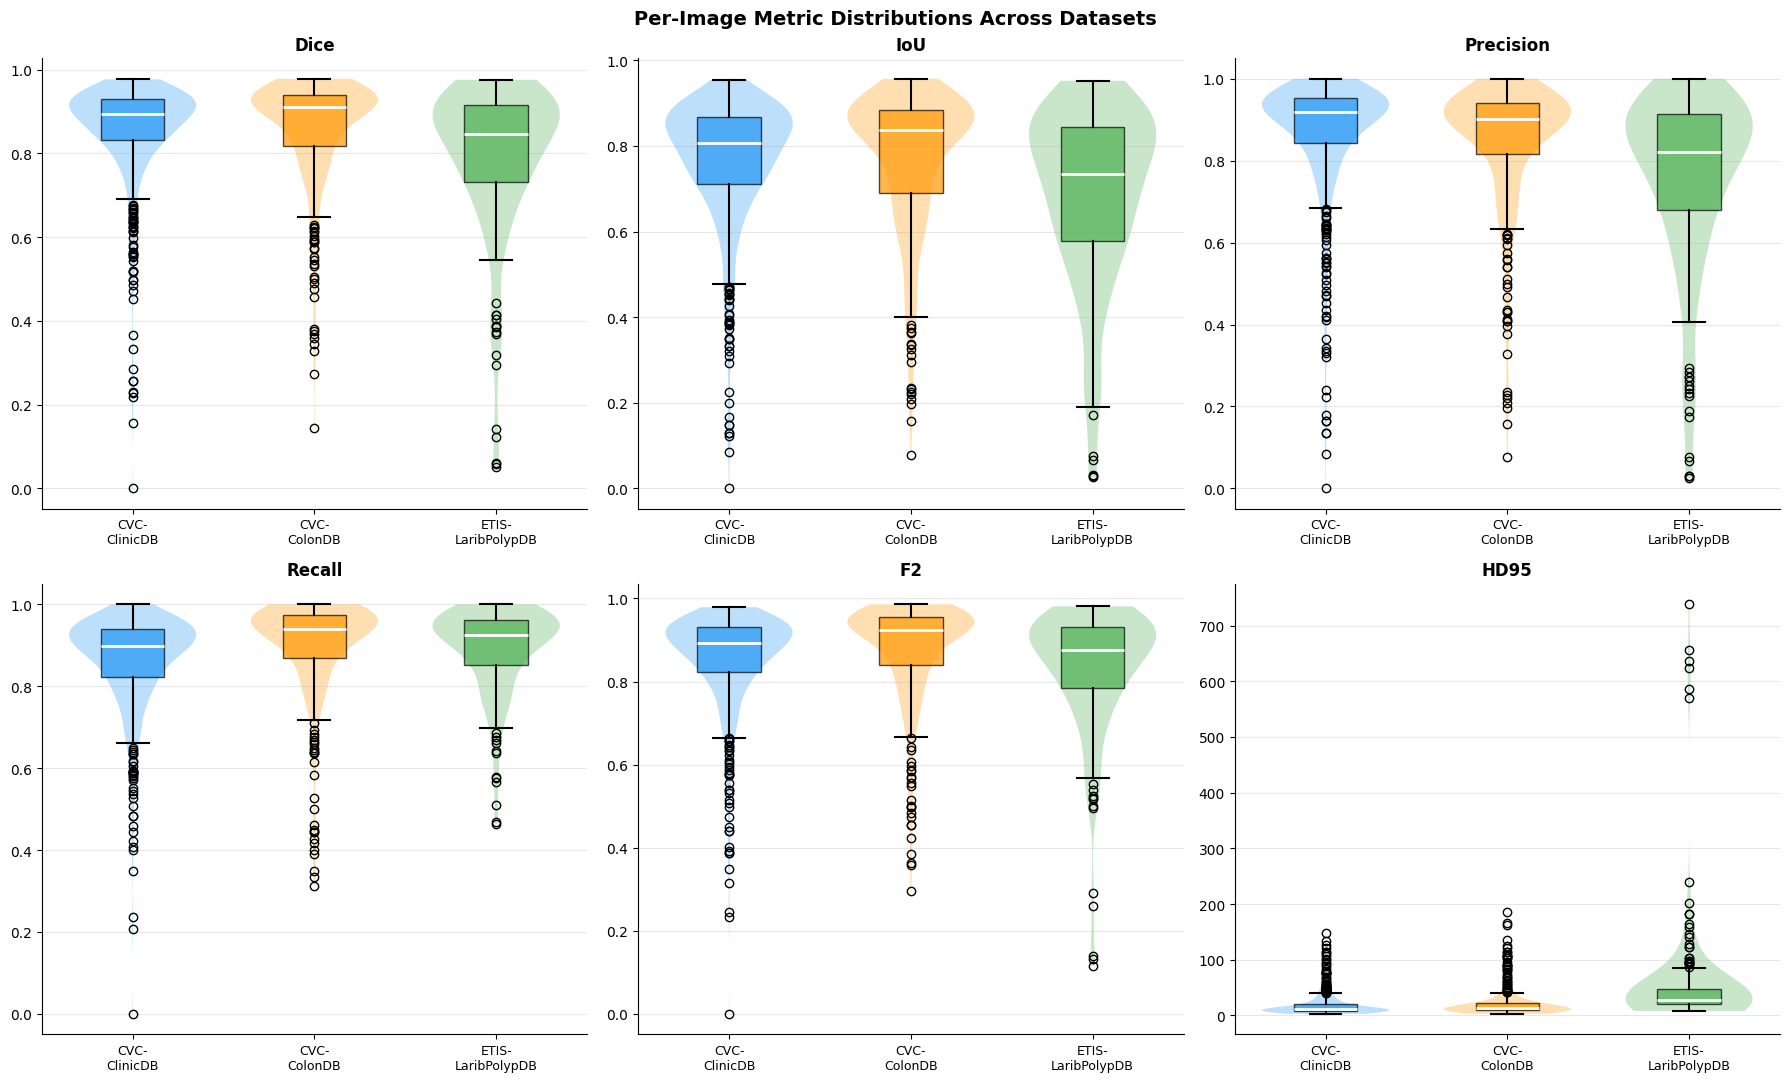

In [11]:
# ============================================================
# Cell 11 — Per-dataset box + violin plots
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
box_metrics = ["Dice", "IoU", "Precision", "Recall", "F2", "HD95"]

for ax, metric in zip(axes.flat, box_metrics):
    data = [all_results[ds][metric].dropna().values for ds in ds_names]

    parts = ax.violinplot(data, positions=range(n_ds), showmedians=False,
                          showextrema=False, widths=0.7)
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(colors[i])
        pc.set_alpha(0.3)

    bp = ax.boxplot(data, positions=range(n_ds), widths=0.35, patch_artist=True,
                    medianprops=dict(color='white', linewidth=2),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5))
    for i, patch in enumerate(bp['boxes']):
        patch.set_facecolor(colors[i])
        patch.set_alpha(0.7)

    ax.set_xticks(range(n_ds))
    xlabels = [n.replace('CVC-', 'CVC-\n').replace('ETIS-', 'ETIS-\n') for n in ds_names]
    ax.set_xticklabels(xlabels, fontsize=9)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Per-Image Metric Distributions Across Datasets',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("cross_dataset_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

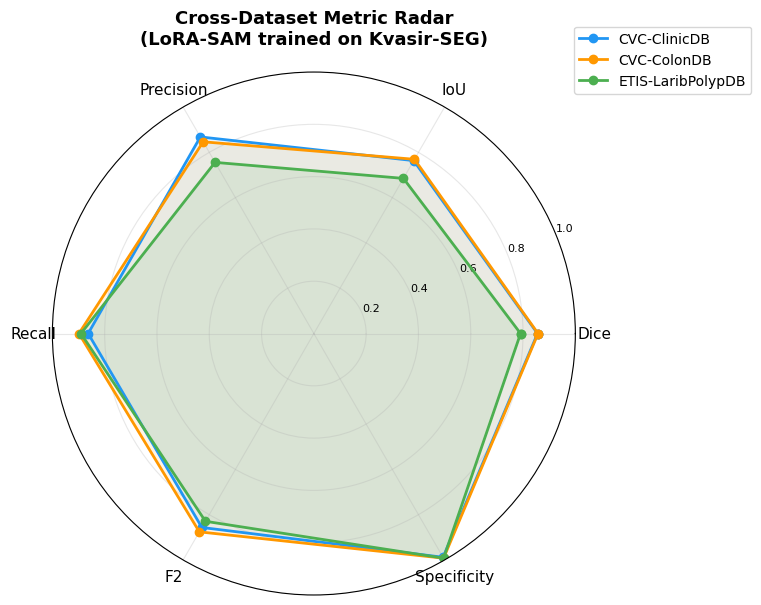

In [12]:
# ============================================================
# Cell 12 — Radar chart: multi-metric comparison
# ============================================================
radar_metrics = ["Dice", "IoU", "Precision", "Recall", "F2", "Specificity"]
N_m = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, N_m, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i, ds_name in enumerate(ds_names):
    vals = [all_results[ds_name][m].dropna().mean() for m in radar_metrics]
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', linewidth=2, label=ds_name,
            color=colors[i], markersize=6)
    ax.fill(angles, vals, alpha=0.1, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_metrics, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=8)
ax.set_title('Cross-Dataset Metric Radar\n(LoRA-SAM trained on Kvasir-SEG)',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("cross_dataset_radar.png", dpi=150, bbox_inches="tight")
plt.show()

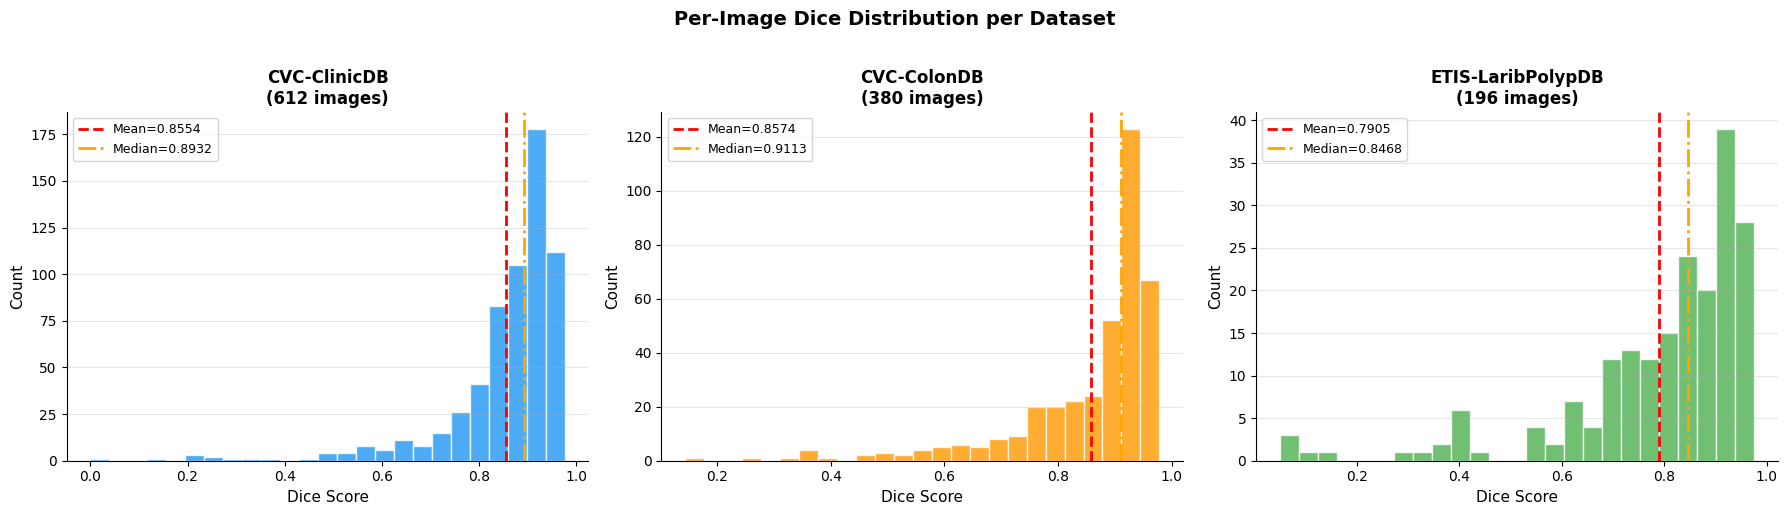

In [13]:
# ============================================================
# Cell 13 — Per-dataset Dice histograms
# ============================================================
fig, axes = plt.subplots(1, n_ds, figsize=(6 * n_ds, 5))
if n_ds == 1:
    axes = [axes]

for ax, ds_name, color in zip(axes, ds_names, colors):
    dice_vals = all_results[ds_name]["Dice"].values
    ax.hist(dice_vals, bins=25, color=color, edgecolor='white', alpha=0.8)
    ax.axvline(dice_vals.mean(), color='red', ls='--', lw=2,
               label=f'Mean={dice_vals.mean():.4f}')
    ax.axvline(np.median(dice_vals), color='orange', ls='-.', lw=2,
               label=f'Median={np.median(dice_vals):.4f}')
    ax.set_xlabel('Dice Score', fontsize=11)
    ax.set_ylabel('Count', fontsize=11)
    ax.set_title(f'{ds_name}\n({len(dice_vals)} images)',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Per-Image Dice Distribution per Dataset',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("cross_dataset_dice_hist.png", dpi=150, bbox_inches="tight")
plt.show()

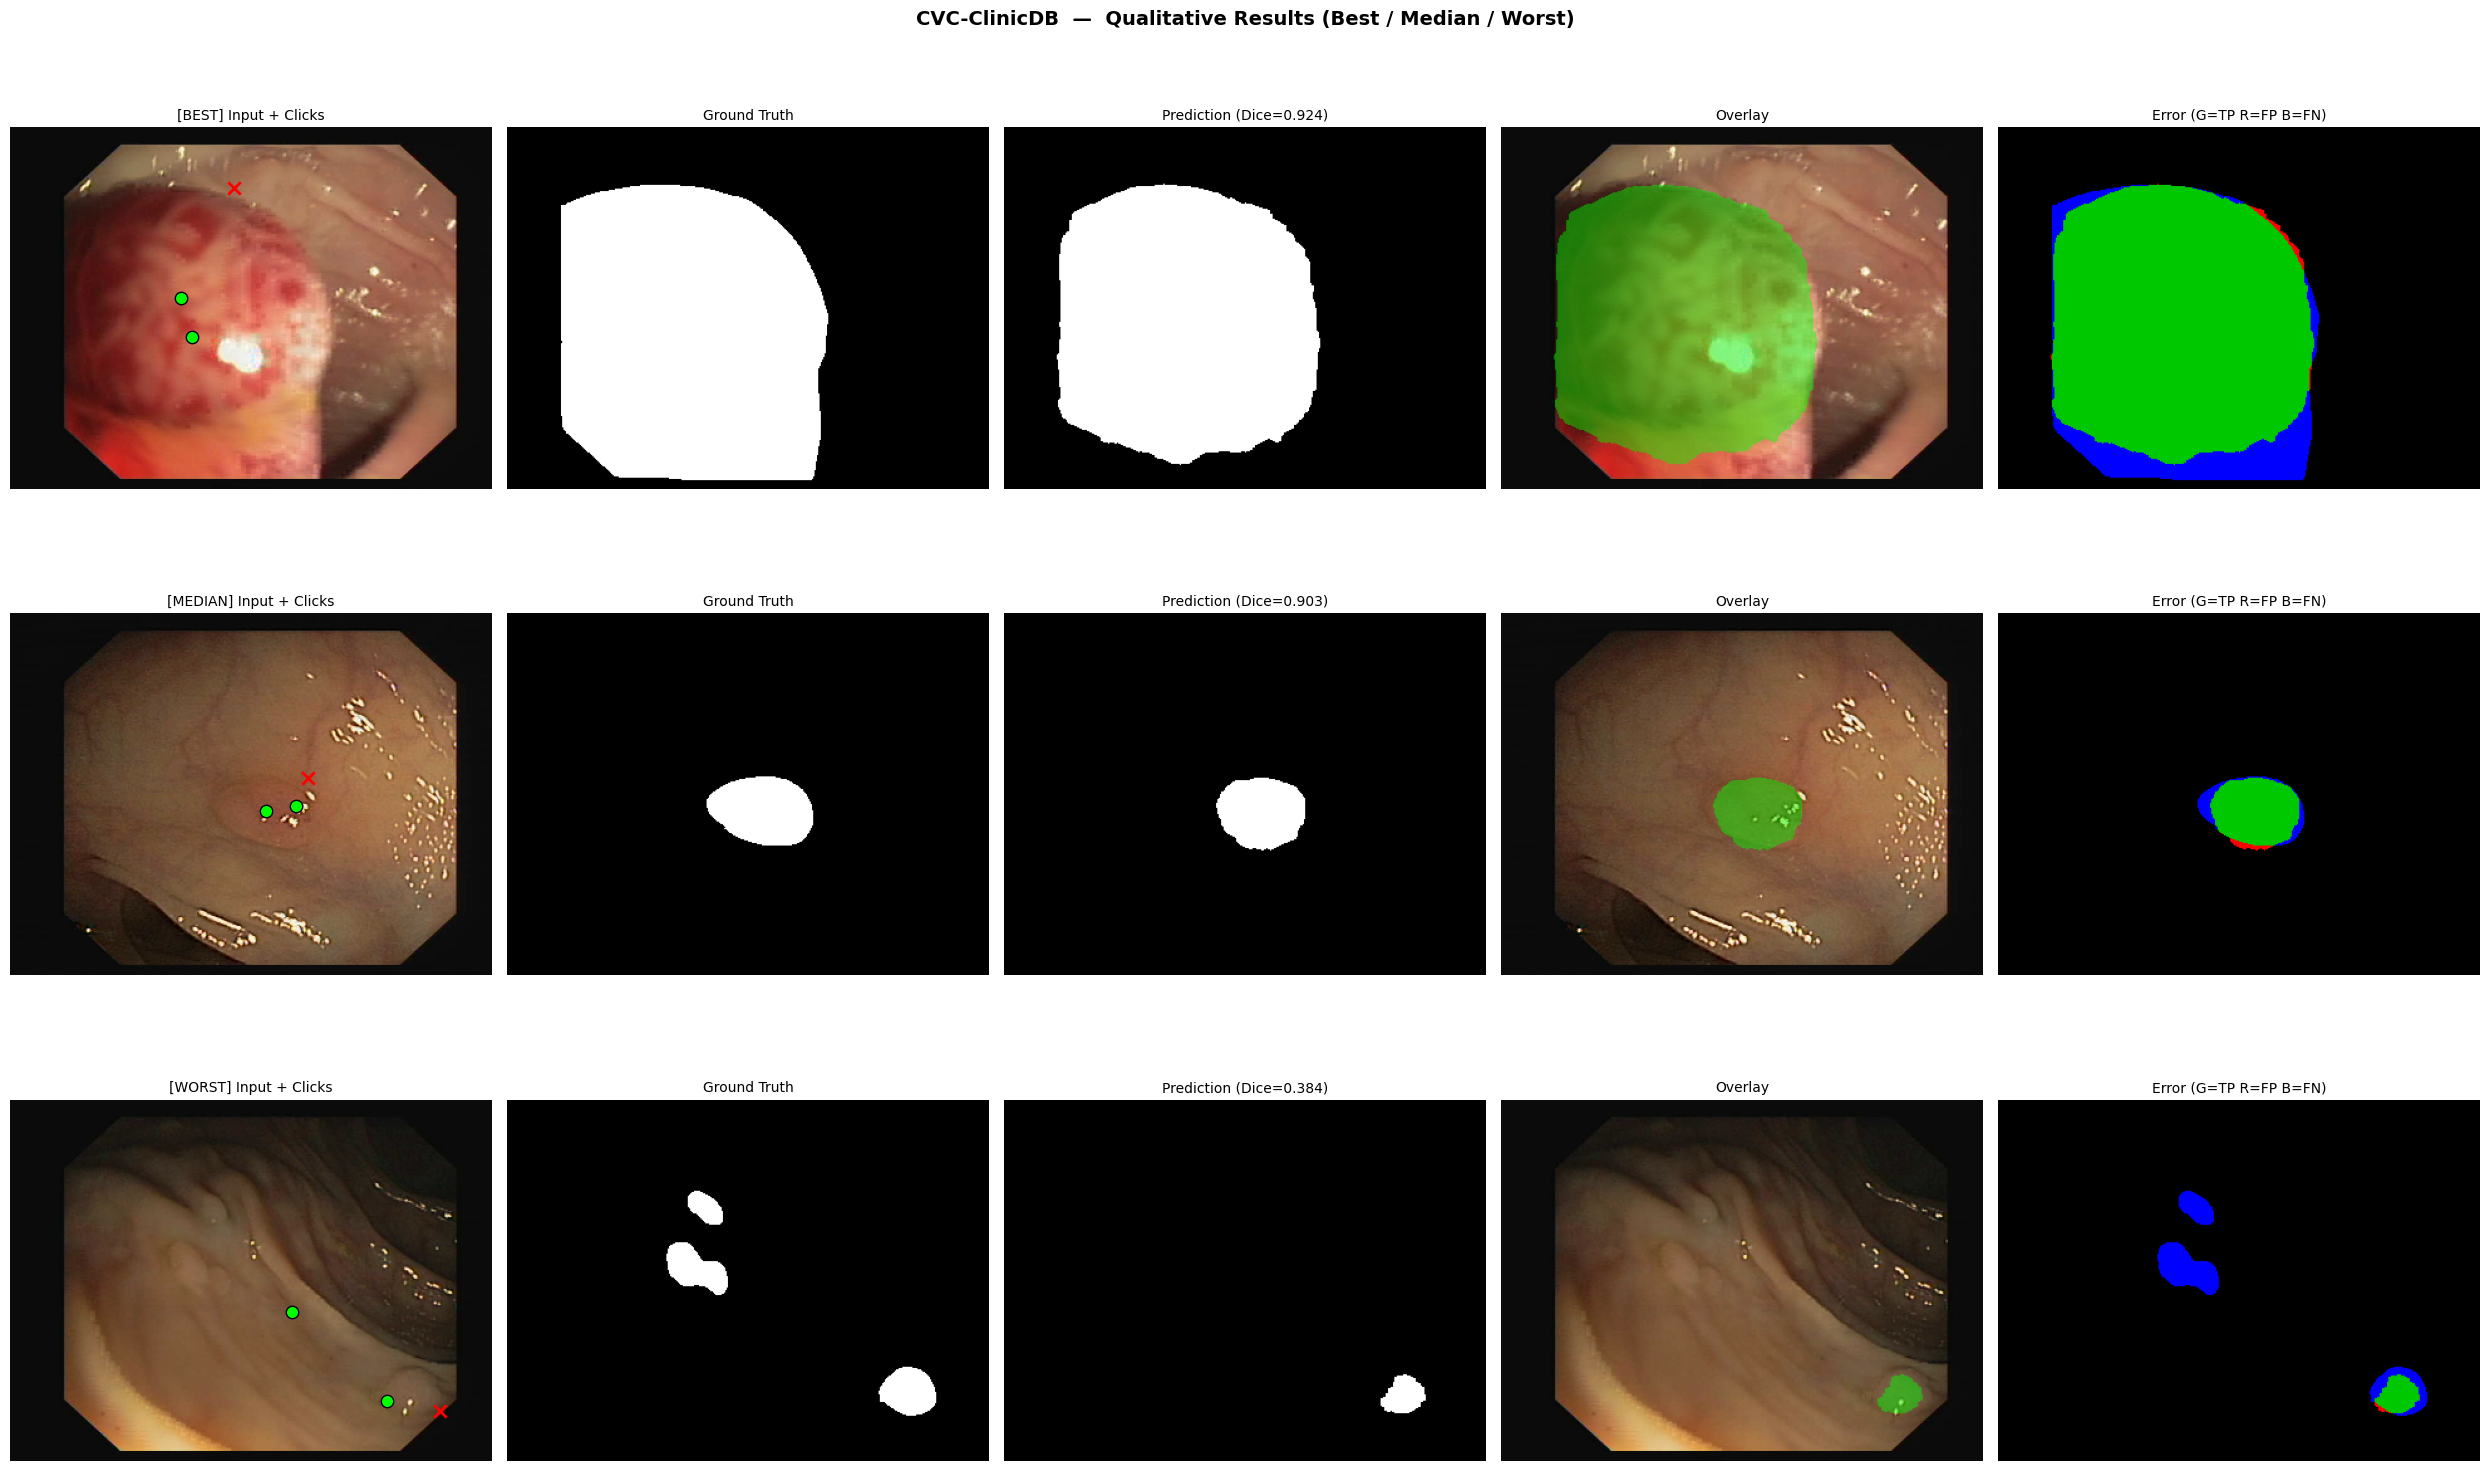

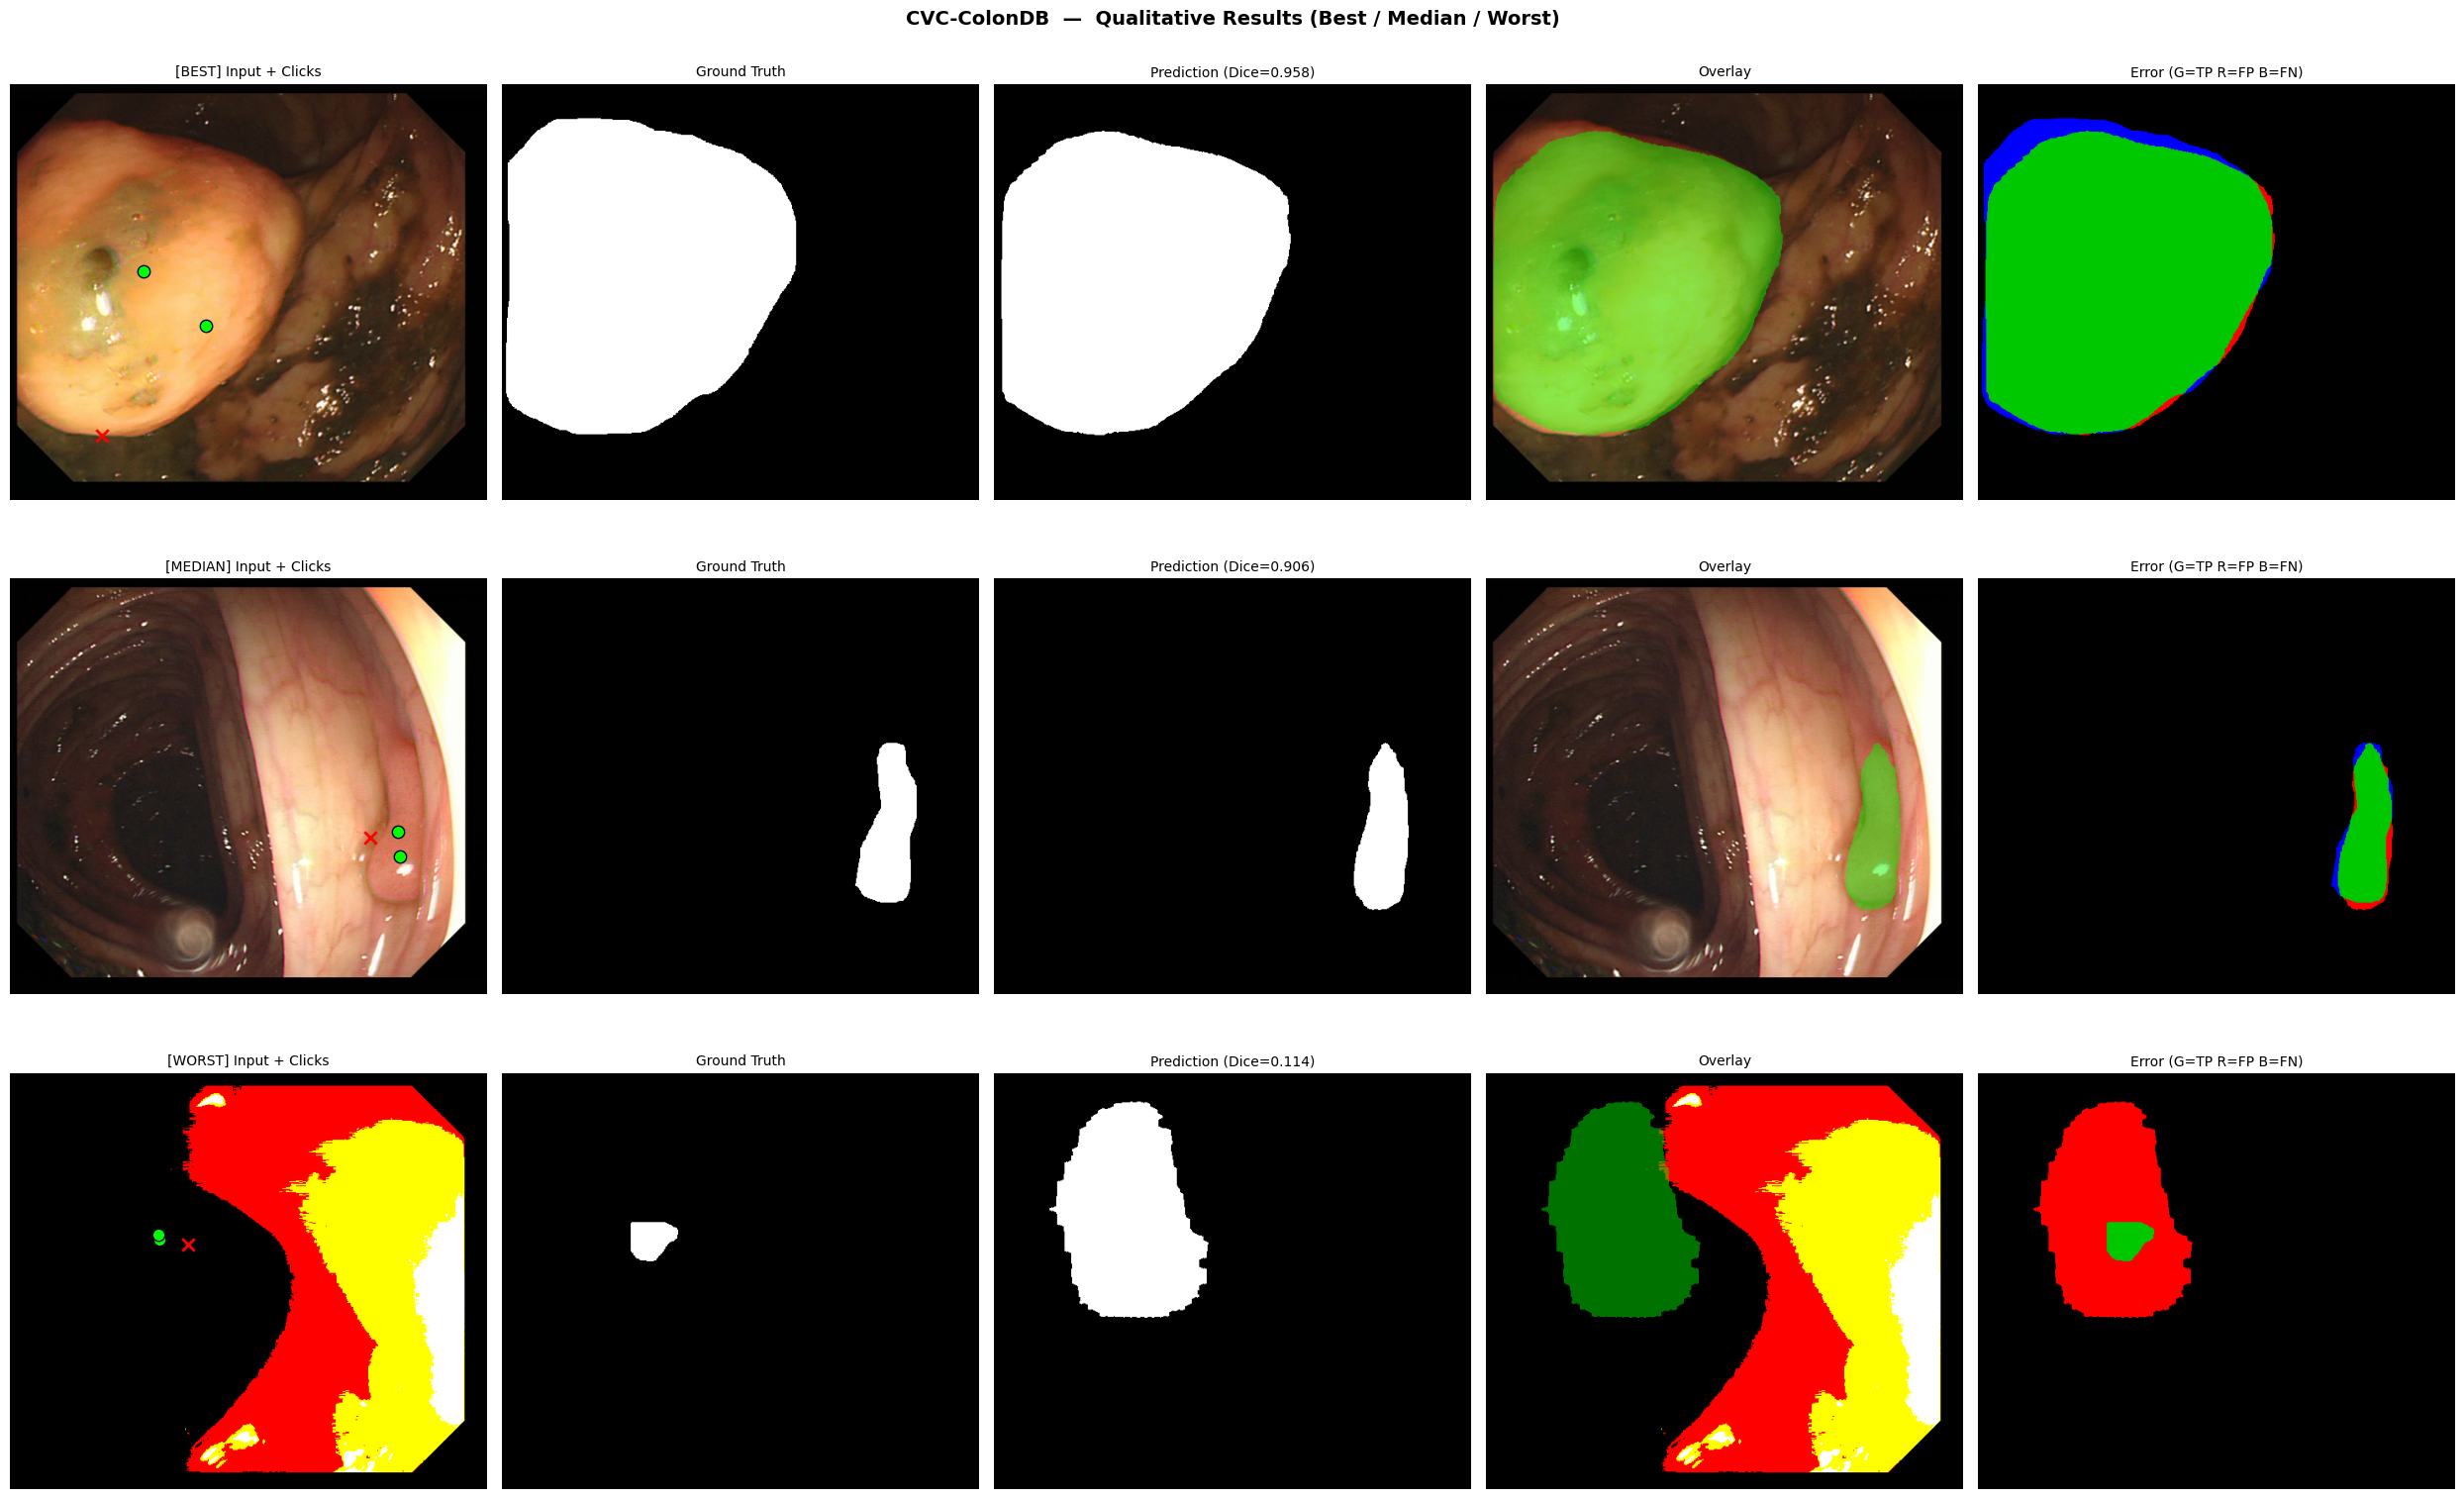

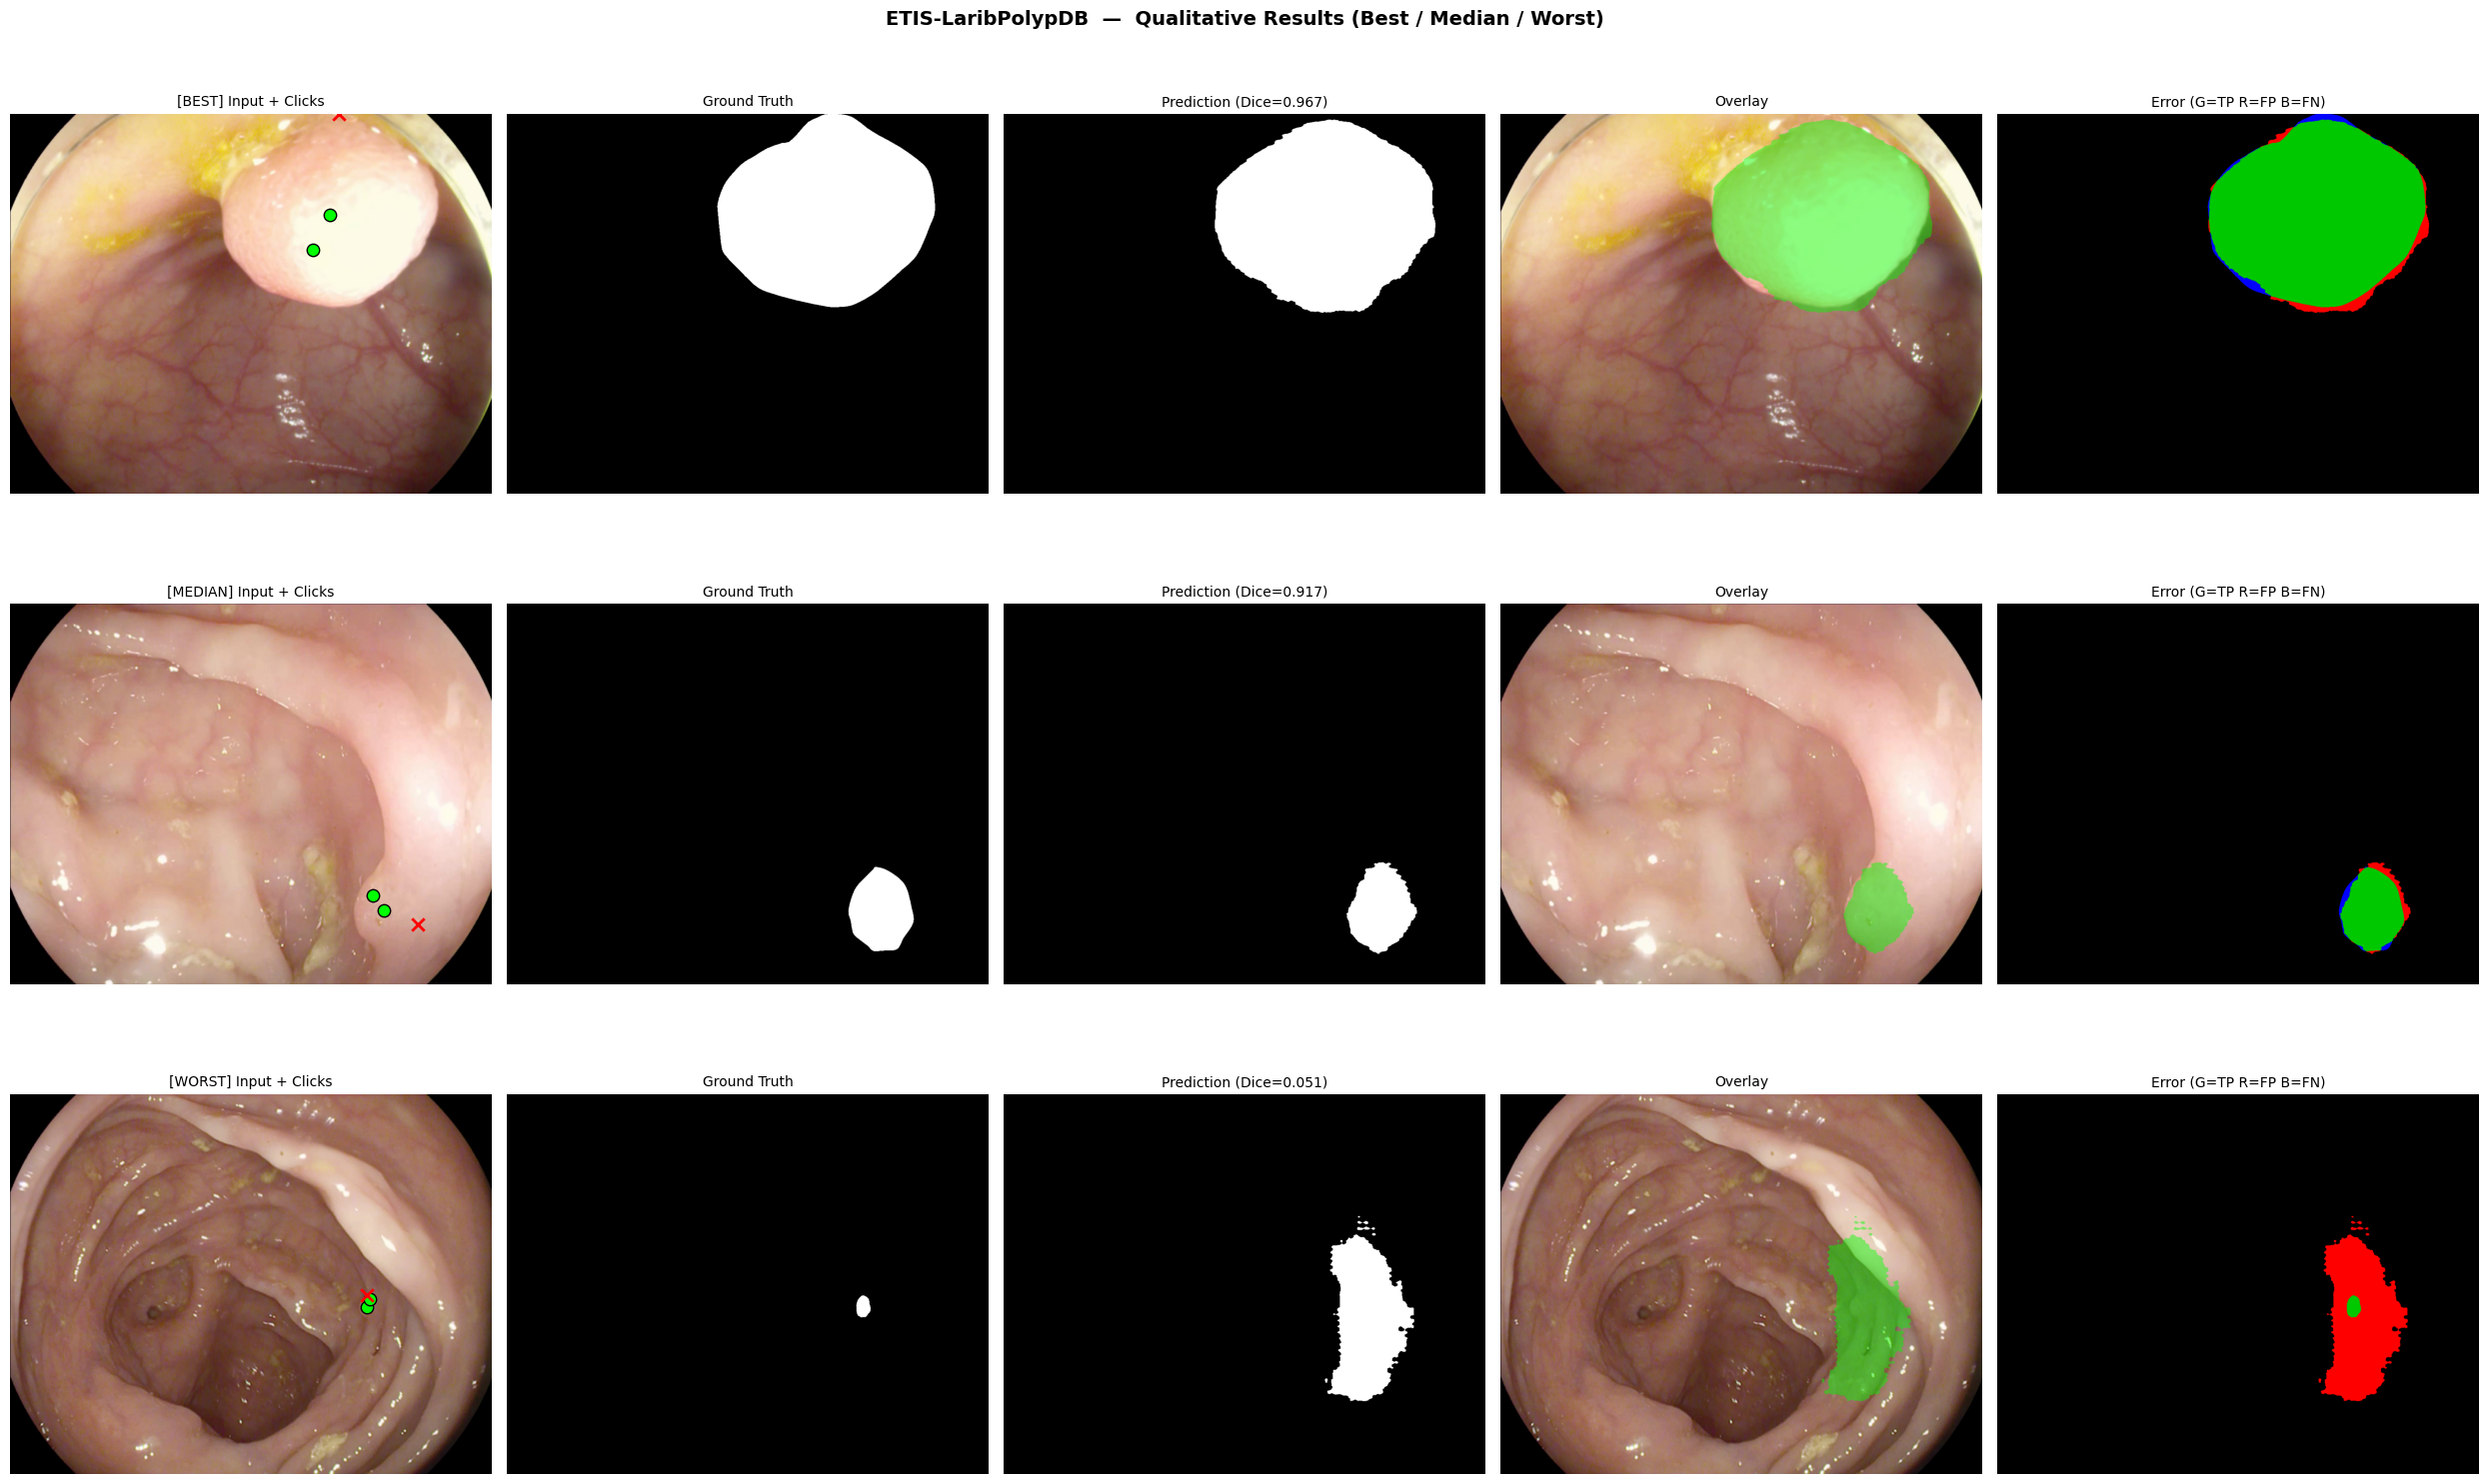

Qualitative results saved for all datasets.


In [14]:
# ============================================================
# Cell 14 — Qualitative results: best / median / worst per dataset
# ============================================================
def overlay(img, mask01, color=(0, 255, 0), alpha=0.45):
    out = img.copy().astype(np.float32)
    c = np.array(color, dtype=np.float32)
    out[mask01 == 1] = (1 - alpha) * out[mask01 == 1] + alpha * c
    return out.astype(np.uint8)

def error_map(pred01, gt01):
    h, w = gt01.shape
    err = np.zeros((h, w, 3), dtype=np.uint8)
    err[(pred01 == 1) & (gt01 == 1)] = [0, 200, 0]    # TP green
    err[(pred01 == 1) & (gt01 == 0)] = [255, 0, 0]    # FP red
    err[(pred01 == 0) & (gt01 == 1)] = [0, 0, 255]    # FN blue
    return err

for ds_name in ds_names:
    df = all_results[ds_name].sort_values("Dice").reset_index(drop=True)
    ds_obj = data_loaders[ds_name].dataset

    picks = OrderedDict()
    picks["BEST"]   = df.iloc[-1]
    picks["MEDIAN"] = df.iloc[len(df) // 2]
    picks["WORST"]  = df.iloc[0]

    name_to_idx = {ds_obj.pairs[i][0]: i for i in range(len(ds_obj))}

    fig, axes = plt.subplots(3, 5, figsize=(25, 16))

    for row, (label, row_data) in enumerate(picks.items()):
        fname = row_data["name"]
        idx = name_to_idx.get(fname)
        if idx is None:
            continue
        image_t, points_t, labels_t, mask_t, (H, W), name = ds_obj[idx]

        img_path = os.path.join(DATASETS[ds_name]['img_dir'], fname)
        img_rgb = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        gt01 = (mask_t.numpy() > 0.5).astype(np.uint8)

        logits = predict_tta(image_t, points_t, labels_t, (H, W))
        probs = torch.sigmoid(logits)[0, 0].cpu().numpy()
        pred01 = postprocess((probs > 0.5).astype(np.uint8))
        met = compute_metrics(pred01, gt01)

        _, h_r, w_r = image_t.shape
        pts_orig = points_t.numpy().copy()
        pts_orig[:, 0] *= (W / w_r)
        pts_orig[:, 1] *= (H / h_r)
        pt_labels = labels_t.numpy()

        # Column 0: Input + clicks
        axes[row, 0].imshow(img_rgb)
        fg = pts_orig[pt_labels == 1]
        bg = pts_orig[pt_labels == 0]
        if len(fg):
            axes[row, 0].scatter(fg[:, 0], fg[:, 1], c='lime', s=80,
                                 marker='o', edgecolors='black',
                                 linewidths=1, zorder=5)
        if len(bg):
            axes[row, 0].scatter(bg[:, 0], bg[:, 1], c='red', s=80,
                                 marker='x', linewidths=2, zorder=5)
        axes[row, 0].set_title(f'[{label}] Input + Clicks', fontsize=10)
        axes[row, 0].axis('off')

        # Column 1: Ground truth
        axes[row, 1].imshow(gt01, cmap='gray')
        axes[row, 1].set_title('Ground Truth', fontsize=10)
        axes[row, 1].axis('off')

        # Column 2: Prediction
        axes[row, 2].imshow(pred01, cmap='gray')
        axes[row, 2].set_title(f'Prediction (Dice={met["Dice"]:.3f})', fontsize=10)
        axes[row, 2].axis('off')

        # Column 3: Overlay
        axes[row, 3].imshow(overlay(img_rgb, pred01))
        axes[row, 3].set_title('Overlay', fontsize=10)
        axes[row, 3].axis('off')

        # Column 4: Error map
        axes[row, 4].imshow(error_map(pred01, gt01))
        axes[row, 4].set_title('Error (G=TP R=FP B=FN)', fontsize=10)
        axes[row, 4].axis('off')

    fig.suptitle(f'{ds_name}  —  Qualitative Results (Best / Median / Worst)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    safe = ds_name.lower().replace('-', '_')
    plt.savefig(f"qual_{safe}.png", dpi=150, bbox_inches="tight")
    plt.show()

print("Qualitative results saved for all datasets.")

In [15]:
# ============================================================
# Cell 15 — Statistical analysis + generalization report
# ============================================================
print("=" * 85)
print("  STATISTICAL ANALYSIS")
print("=" * 85)

# Pairwise Mann-Whitney U tests
if n_ds >= 2:
    print("\n--- Pairwise Mann-Whitney U test (Dice scores) ---")
    print(f"  {'Comparison':<45} {'U-stat':>10} {'p-value':>12} {'Sig?':>10}")
    print(f"  {'-'*45} {'-'*10} {'-'*12} {'-'*10}")
    for i in range(n_ds):
        for j in range(i + 1, n_ds):
            d1 = all_results[ds_names[i]]["Dice"].dropna().values
            d2 = all_results[ds_names[j]]["Dice"].dropna().values
            u_stat, p_val = stats.mannwhitneyu(d1, d2, alternative='two-sided')
            sig = "YES" if p_val < 0.05 else "no"
            label = f"{ds_names[i]} vs {ds_names[j]}"
            print(f"  {label:<45} {u_stat:>10.0f} {p_val:>12.6f} {sig:>10}")

# Detailed per-dataset statistics
print(f"\n{'='*85}")
print("  PER-DATASET DETAILED STATISTICS")
print(f"{'='*85}")
for ds_name in ds_names:
    df = all_results[ds_name]
    print(f"\n  {ds_name} ({len(df)} images):")
    print(f"  {'Metric':<14} {'Mean':>8} {'Std':>8} {'Median':>8} "
          f"{'Min':>8} {'Max':>8} {'95% CI':>18}")
    print(f"  {'-'*14} {'-'*8} {'-'*8} {'-'*8} {'-'*8} {'-'*8} {'-'*18}")
    for m in METRIC_COLS:
        v = df[m].dropna().values
        ci_lo, ci_hi = np.percentile(v, [2.5, 97.5])
        print(f"  {m:<14} {v.mean():>8.4f} {v.std():>8.4f} "
              f"{np.median(v):>8.4f} {v.min():>8.4f} {v.max():>8.4f} "
              f"[{ci_lo:.4f}, {ci_hi:.4f}]")

# Failure analysis
print(f"\n{'='*85}")
print("  FAILURE ANALYSIS (images with Dice < 0.5)")
print(f"{'='*85}")
for ds_name in ds_names:
    df = all_results[ds_name]
    failures = df[df["Dice"] < 0.5]
    pct = 100 * len(failures) / len(df)
    print(f"\n  {ds_name}: {len(failures)}/{len(df)} failures ({pct:.1f}%)")
    if len(failures) > 0:
        print(f"    Worst 5 images:")
        for _, r in failures.nsmallest(5, "Dice").iterrows():
            print(f"      {r['name']}: Dice={r['Dice']:.4f}  IoU={r['IoU']:.4f}")

# Overall generalization summary
print(f"\n{'='*85}")
print("  GENERALIZATION SUMMARY")
print(f"{'='*85}")
print(f"\n  {'Dataset':<22} {'N':>6} {'Dice':>10} {'IoU':>10}")
print(f"  {'-'*22} {'-'*6} {'-'*10} {'-'*10}")
for ds_name in ds_names:
    df = all_results[ds_name]
    print(f"  {ds_name:<22} {len(df):>6} "
          f"{df['Dice'].mean():>10.4f} {df['IoU'].mean():>10.4f}")
print(f"  {'-'*22} {'-'*6} {'-'*10} {'-'*10}")
print(f"  {'OVERALL':<22} {len(df_all):>6} "
      f"{df_all['Dice'].mean():>10.4f} {df_all['IoU'].mean():>10.4f}")
print(f"{'='*85}")

  STATISTICAL ANALYSIS

--- Pairwise Mann-Whitney U test (Dice scores) ---
  Comparison                                        U-stat      p-value       Sig?
  --------------------------------------------- ---------- ------------ ----------
  CVC-ClinicDB vs CVC-ColonDB                       105945     0.018483        YES
  CVC-ClinicDB vs ETIS-LaribPolypDB                  73152     0.000004        YES
  CVC-ColonDB vs ETIS-LaribPolypDB                   47329     0.000000        YES

  PER-DATASET DETAILED STATISTICS

  CVC-ClinicDB (612 images):
  Metric             Mean      Std   Median      Min      Max             95% CI
  -------------- -------- -------- -------- -------- -------- ------------------
  Dice             0.8554   0.1235   0.8932   0.0000   0.9766 [0.5171, 0.9623]
  IoU              0.7635   0.1522   0.8070   0.0000   0.9542 [0.3487, 0.9273]
  Precision        0.8682   0.1472   0.9180   0.0000   1.0000 [0.4196, 0.9892]
  Recall           0.8633   0.1184   0.8985   

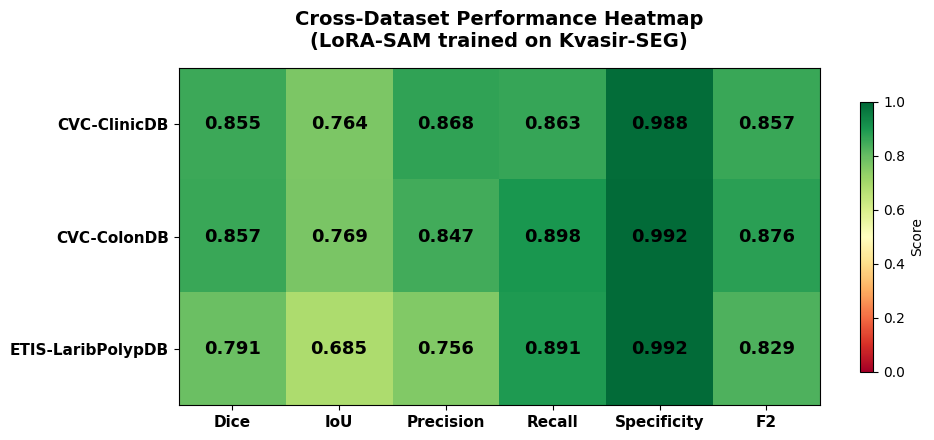

In [16]:
# ============================================================
# Cell 16 — Metric heatmap across datasets
# ============================================================
heatmap_metrics = ["Dice", "IoU", "Precision", "Recall", "Specificity", "F2"]
data_matrix = np.zeros((n_ds, len(heatmap_metrics)))
for i, ds_name in enumerate(ds_names):
    for j, m in enumerate(heatmap_metrics):
        data_matrix[i, j] = all_results[ds_name][m].dropna().mean()

fig, ax = plt.subplots(figsize=(10, max(4, n_ds * 1.5)))
im = ax.imshow(data_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)

for i in range(n_ds):
    for j in range(len(heatmap_metrics)):
        val = data_matrix[i, j]
        color = 'white' if val < 0.5 else 'black'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                fontsize=13, fontweight='bold', color=color)

ax.set_xticks(range(len(heatmap_metrics)))
ax.set_xticklabels(heatmap_metrics, fontsize=11, fontweight='bold')
ax.set_yticks(range(n_ds))
ax.set_yticklabels(ds_names, fontsize=11, fontweight='bold')
ax.set_title('Cross-Dataset Performance Heatmap\n'
             '(LoRA-SAM trained on Kvasir-SEG)',
             fontsize=14, fontweight='bold', pad=15)
plt.colorbar(im, ax=ax, shrink=0.8, label='Score')
plt.tight_layout()
plt.savefig("cross_dataset_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
# ============================================================
# Cell 17 — Save all results
# ============================================================
output_dir = "/kaggle/working"

# Per-image results (all datasets combined)
df_all.to_csv(os.path.join(output_dir, "cross_dataset_all_results.csv"), index=False)

# Per-dataset CSVs
for ds_name, df in all_results.items():
    safe = ds_name.lower().replace('-', '_').replace(' ', '_')
    df.to_csv(os.path.join(output_dir, f"results_{safe}.csv"), index=False)

# Summary table
summary_data = []
for ds_name, df in all_results.items():
    row = {"Dataset": ds_name, "N_images": len(df)}
    for m in METRIC_COLS:
        v = df[m].dropna()
        row[f"{m}_mean"] = round(v.mean(), 4)
        row[f"{m}_std"]  = round(v.std(), 4)
    summary_data.append(row)

df_summary_out = pd.DataFrame(summary_data)
df_summary_out.to_csv(os.path.join(output_dir, "cross_dataset_summary.csv"), index=False)

print("=" * 70)
print("  ALL RESULTS SAVED")
print("=" * 70)
print(f"\n  Files in {output_dir}:")
print("    cross_dataset_all_results.csv  (per-image, all datasets)")
print("    cross_dataset_summary.csv      (aggregated summary)")
for ds_name in ds_names:
    safe = ds_name.lower().replace('-', '_').replace(' ', '_')
    print(f"    results_{safe}.csv")

print("\n  Figures:")
for fig_name in ["cross_dataset_bars", "cross_dataset_hd95",
                 "cross_dataset_boxplots", "cross_dataset_radar",
                 "cross_dataset_dice_hist", "cross_dataset_heatmap"]:
    print(f"    {fig_name}.png")
for ds_name in ds_names:
    safe = ds_name.lower().replace('-', '_')
    print(f"    qual_{safe}.png")

print(f"\n{'='*70}")
print("  FINAL SUMMARY")
print(f"{'='*70}")
print(df_summary_out[["Dataset", "N_images",
                       "Dice_mean", "Dice_std",
                       "IoU_mean", "IoU_std"]].to_string(index=False))
overall_dice = df_all['Dice'].mean()
overall_iou  = df_all['IoU'].mean()
print(f"\n  Overall Dice: {overall_dice:.4f} +/- {df_all['Dice'].std():.4f}")
print(f"  Overall IoU:  {overall_iou:.4f} +/- {df_all['IoU'].std():.4f}")
print(f"{'='*70}")
print("\nDone! Ready for paper / thesis.")

  ALL RESULTS SAVED

  Files in /kaggle/working:
    cross_dataset_all_results.csv  (per-image, all datasets)
    cross_dataset_summary.csv      (aggregated summary)
    results_cvc_clinicdb.csv
    results_cvc_colondb.csv
    results_etis_laribpolypdb.csv

  Figures:
    cross_dataset_bars.png
    cross_dataset_hd95.png
    cross_dataset_boxplots.png
    cross_dataset_radar.png
    cross_dataset_dice_hist.png
    cross_dataset_heatmap.png
    qual_cvc_clinicdb.png
    qual_cvc_colondb.png
    qual_etis_laribpolypdb.png

  FINAL SUMMARY
          Dataset  N_images  Dice_mean  Dice_std  IoU_mean  IoU_std
     CVC-ClinicDB       612     0.8554    0.1236    0.7635   0.1523
      CVC-ColonDB       380     0.8574    0.1312    0.7694   0.1676
ETIS-LaribPolypDB       196     0.7905    0.1856    0.6850   0.2096

  Overall Dice: 0.8454 +/- 0.1401
  Overall IoU:  0.7525 +/- 0.1704

Done! Ready for paper / thesis.
